# Lab 13 --- CNNs

Esraaj Sarkar Gupta on the 26th of April, 2026

In [1]:
# ---- Imports ---- #
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

2026-04-26 03:00:55.058947: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-26 03:00:55.587322: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-26 03:00:59.437140: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# ---- Load Dataset ---- #
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Reshape to (28, 28, 1) for the CNN
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test,   -1)

In [3]:
# ---- Build Model ---- #
model = keras.Sequential(
    [
        keras.Input(shape=(28, 28, 1)),
        # -- Feature Extraction Layers -- #

        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", name="Conv_1"),
        layers.MaxPooling2D(pool_size=(2, 2), name="Pool_1"),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", name="Conv_2"),
        layers.MaxPooling2D(pool_size=(2, 2), name="Pool_2"),

        # -- Feature Classification Layers -- #
        layers.Flatten(name="Flatten"),
        layers.Dense(128, activation="relu", name="Dense_1"),
        layers.Dropout(0.5), # Added for regularization
        layers.Dense(10, activation="softmax", name="Output")
    ]
)

model.summary()

2026-04-26 03:04:48.556208: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_1 (MaxPooling2D)           │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_2 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# ---- Training the Model ---- #
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Train the model
# Author's Note: Even 5 epochs took a while on my hardware. This is what I get using iGPUs
history = model.fit(x_train, y_train, batch_size=128, epochs=5, validation_split=0.1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.9008 - loss: 0.3212 - val_accuracy: 0.9790 - val_loss: 0.0691
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9682 - loss: 0.1061 - val_accuracy: 0.9867 - val_loss: 0.0456
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.9768 - loss: 0.0767 - val_accuracy: 0.9880 - val_loss: 0.0416
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.9815 - loss: 0.0614 - val_accuracy: 0.9873 - val_loss: 0.0422
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.9844 - loss: 0.0521 - val_accuracy: 0.9885 - val_loss: 0.0373


In [5]:
# ---- Performance Metrics ---- #
test_loss, test_acc = model.evaluate(x_test, y_test)

print("\n----------------------------------\n")
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")
print("\n----------------------------------\n")


# Generate Predictions
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report (for classifying and reporting)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9895 - loss: 0.0275

----------------------------------

Final Test Loss: 0.0275
Final Test Accuracy: 0.9895

----------------------------------

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0

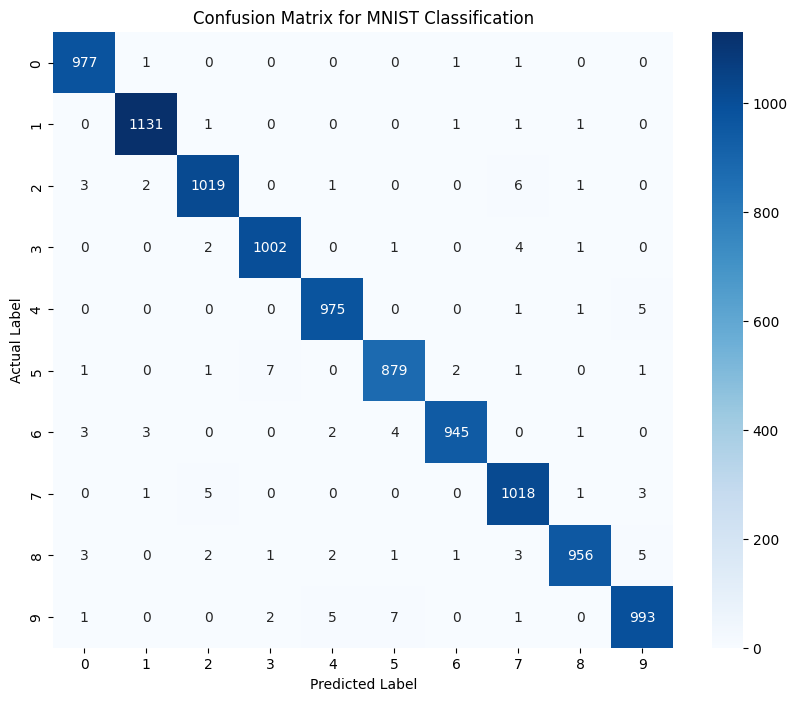

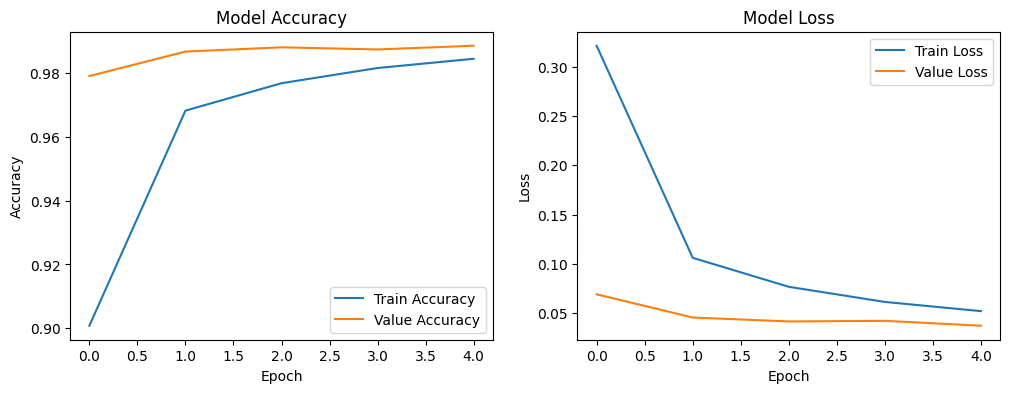

In [ ]:
# ---- Data Visualization ---- #

# COnfusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')   # Such a peaceful color. It would be appropriate for the moon to be blue.
plt.title('Confusion Matrix for MNIST Classification')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.show()

# Training History
plt.figure(figsize=(12, 4))
# ---- ---- #
plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Value Accuracy')
plt.title('Model Accuracy')

plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# ---- ---- #

plt.subplot(1, 2, 2)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Value Loss')

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()

# I have an interview this monday. I really want this one too. Wish me luck!

# Report

#### Question 1
For feature extraction, 4 layers were used -- 2 convolutional layers and 2 MaxPooling layers. On the other hand, for feature classification, 3 layers were used -- one flatten layer to transition data, followed directly by two dense layers.

#### Question 2
32 kernels of size 3x3 were used to extract features on the MNIST images in the first convolutional layer.

#### Question 3
Max Pooling with a 2x2 window was used in this lab. This is done to progressively reduce the spatial size of the representation. This decreases the number of parameters and effectively reduces the computational load on the network. This helps overfitting, and also makes the detection of features invariant of small translations in the input image.

#### Question 4
The following list outlines the dimensions in each layer.

* Input: 28x28x1
* Conv2D (Layer 1): 26x26x32
* MaxPooling2D (Layer 1): 13x13x32
* Conv2D (Layer 2): 11x11x64
* MaxPooling2D (Layer 2): 5x5x64
* Flatten: 1600
* Dense (Hidden): 128
* Dense (Output): 10 


The dimensions reduce for the following reasons --- firstly the standard Convolutional layers (lacking explicit padding) shrink the image slightly since the 3x3 kernel cannot center over the edge pixels in the extremeties of the image. Secondly,the MaxPooling layers purposefully cut the dimensions in half by downsampling 2x2 pixel blocks into single maximum values.

#### Question 5
The outputs of CNNs are converted using the `Softmax` activation function in the final Dense layer. The function converts raw numerical inputs from the network and applies an exponential function to them, normalizing the values so they fall stricly in the interval [0, 1], such that the sums of all the values is exactly equal to 1. This allows us to interpret the outputs as a distinct probability distribution across all 10 classes. 

